# Application results : Evolution of uncertainty on QualiAgro site under the different error scenarios

## For SOC stock difference $D(t)$ between two management practices scenarios (carbon farming (CF) vs baseline), under a static standardised baseline

The baseline design is based on regional conditions for management practices and pedoclimatics inputs variables. With this baseline, the difference of SOC stock between two management practices is computed following this expression : 

$\mu_{D(t)} = \mu_{\Delta C_{CF}}(t) - \mu_{\Delta C_{Baseline*}}(t)$

And its uncertainty as follows : 

$\sigma_{D(t)} = \sqrt{\sigma_{\Delta C_{CF}}^2(t) + \sigma_{\Delta C_{Baseline*}}^2(t)}$

Therefore, we will compute the temporal SOC stock change for each managment practice scenario (Carbon Farming and Baseline) along its uncertainty : $(\mu_{\Delta C_{CF}}, \sigma_{\Delta C_{CF}})$ and $(\mu_{\Delta C_{Baseline}}, \sigma_{\Delta C_{Baseline}})$.


Under this baseline design, the initial conditions con't cancel each other, therefore we use error in initial conditions are considered in the error scenario configurations.

Although not strictly correct, in the code we will often call the SOC stock difference $D(t)$ between two management practices scenarios "carbon_credit" for simplicity.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import csv
import pickle
from scipy.integrate import odeint

from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
from scipy.integrate import cumulative_trapezoid

from pathlib import Path

In [2]:
#%% AMGv2 param from Clivot et al. (2019)

param={}
param['a_calcium'] = 0.0015
param['a_pH']      = 0.112
param['b_pH']      = 8.5
param['a_clay']    = 2.519*0.001
param['a_CN']      = 0.06
param['b_CN']      = 11
param['c_CN']      = 0.8
param['d_CN']      = 0.2
param['a_H']       = 0.03
param['b_H']       = 5.247
param['a_T']       = 25
param['T_ref']     = 15
param['c_T']       = 0.12
param['b_T']       = (param['a_T']-1)*np.exp(param['c_T'] *param['T_ref'] )
param['k0']        = 0.290

### Mineralisation rate function and its uncertainty

In [3]:
# Function to compute the mineralisation rate
def mineralisation_process(data):
    stress={}
    sigma={}
    
    T = data['Temp']
    H = data['P-ETP']
    Clay = data['Clay']
    CaCO3 = data['CaCO3']
    pH = data['pH']
    CN = data['C/N']
    
    # f(A) in Clivot et al. (2019)
    stress['clay_stress']      = np.exp(- param['a_clay'] * Clay)
    
    # f(CaCo3) in Clivot et al. (2019)
    stress['calcium_stress']    = 1/(1+  param['a_calcium']*CaCO3)
    
    # f(pH) in Clivot et al. (2019)
    stress['pH_stress']         = np.exp(-param['a_pH'] * (pH-param['b_pH'])*(pH-param['b_pH']))
    
    # f(C/N) in Clivot et al. (2019)
    u=(CN-param['b_CN'])
    stress['CN_stress']  = 0.8*np.exp(-param['a_CN']*u*u)+0.2
    
    #f(T) in Clivot et al. (2019), here all T>0
    stress['T_stress']= param['a_T']/((1+param['b_T']*np.exp(-param['c_T']*T)))
    
    #f(H) in Clivot et al. (2019)
    stress['H_stress']         = 1/(1+param['a_H']*np.exp((-param['b_H']*H/1000)))
    
    # minéralisation rate k
    stress['mineralisation_rate']  = (param['k0']*stress['CN_stress']* 
                                       stress['calcium_stress'] * stress['pH_stress'] * stress['clay_stress'] ) * stress['H_stress'] * stress['T_stress'] 
    return stress

# Functions defining the contribution to the uncertainty of each pedoclimatic response function modulating the mineralisation rate
def eps_fT(param, T):
    b_T = param['b_T']
    c_T = param['c_T']
    eps = b_T * c_T * np.exp(-c_T*T) / (1 + b_T*np.exp(-c_T*T))
    return eps


def eps_CaCO3(param,CaCO3):
    c_m = param['a_calcium']
    return - c_m/(1+c_m*CaCO3)

def eps_pH(param, pH):
    a_pH = param['a_pH']
    b_pH = param['b_pH']
    return -2*a_pH*(pH-b_pH)

def eps_CN(param,CN):
    a_CN = param['a_CN']
    b_CN = param['b_CN']    
    fp_CN = -1.6 * a_CN *(CN- b_CN)*np.exp(-a_CN *(CN-b_CN)**2)
    f = 0.8 * np.exp(-a_CN*(CN-b_CN)**2) + 0.2
    return fp_CN/f

def eps_Hm(param, Hm):
    a_H = param['a_H']
    b_H = param['b_H']
    eps = (a_H*b_H*np.exp(-b_H*Hm/1000))/(1000*(1+ a_H*np.exp(-b_H*Hm/1000)))
    return eps

# Definition of the standardised static baseline based on regional conditions

- For pedoclimatic input variables, we use the data from five long-term experimental sites available in Clivot et al. (2019) supplemental, that are located around the QualiAgro site. In Clivot et al. (2019), QualiAgro is site n°9, and for the standardised static baseline we use the data from the sites n° 2, 5, 8, 10 and 17 (See Fig. 1 in their study). Since it is a static and standardised baseline, we compute the temporal average and the spatial average of all these sites. In the Supplemental of Clivot et al. (2019), the data are already averaged in time, so we only have to take the spatial average.

- For carbon inputs estimations, we used yield regional statistics from Agreste et al. (2025), spanning 2010-2024. We keep the crop rotation of the QualiAgro treatments, and get the average yield corrsponding from Agreste et al. (2025) to create the time series of carbon inputs for the baseline. Since QualiAgro starts in 1999, and Agreste et al. (2025) database in 2011, we took the average between 2010-2024 when the year were not avalaible.


### For the pedoclimatics variables and the mineralisation rate

In [4]:
#%% sites from Clivot et al. (2019)

data_clivot = pd.read_csv('../data/work_scenario_Clivot_et_al_2019_suplemental.csv')

list_id_sites_for_baseline = [2,5,8,10,17]

data_for_baseline_region = data_clivot[np.isin(data_clivot['id_Site'],list_id_sites_for_baseline)]


In [5]:
# For the mean values, we took the average of the five sites for each variable
static_baseline_region_mean = data_for_baseline_region[['Temp', 'P', 'PET', 'P-ETP','Clay', 'Silt', 'Sand', 'CaCO3', 'pH', 'C/N',
'Initial SOC content', 'Bulk density', 'Rock fragment','Initial SOC stock', 'Mean SD',]].mean()

# For the errors, we took the standard deviation of the five sites for each variable
static_baseline_region_std = data_for_baseline_region[['Temp', 'P', 'PET', 'P-ETP','Clay', 'Silt', 'Sand', 'CaCO3', 'pH', 'C/N',
'Initial SOC content', 'Bulk density', 'Rock fragment','Initial SOC stock', 'Mean SD',]].std()

# we store the mean and std of the baseline in a data frame
static_baseline_region = pd.DataFrame({'Mean':static_baseline_region_mean, 'std':static_baseline_region_std})

# we compute the mean mineralisation rate of the baseline
mu_k_baseline = mineralisation_process(static_baseline_region_mean)['mineralisation_rate']


# we compute the uncertainty of the mineralisation rate
static_baseline_region_std['w_T'] = (eps_fT(param, static_baseline_region_mean['Temp'])*static_baseline_region_std['Temp'])**2
static_baseline_region_std['w_H'] = (eps_Hm(param, static_baseline_region_mean['P-ETP'])**2)*static_baseline_region_std['P-ETP']
static_baseline_region_std['w_CaCO3'] = (eps_CaCO3(param, static_baseline_region_mean['CaCO3'])*static_baseline_region_std['CaCO3'])**2
static_baseline_region_std['w_Clay'] = (static_baseline_region_std['Clay']*param['a_clay'] )**2
static_baseline_region_std['w_pH'] = (eps_pH(param, static_baseline_region_mean['pH'])*static_baseline_region_std['pH'])**2
static_baseline_region_std['w_CN'] = (eps_CN(param, static_baseline_region_mean['C/N'])*static_baseline_region_std['C/N'])**2

static_baseline_region_std['sigma_k_2'] = mu_k_baseline*mu_k_baseline * (static_baseline_region_std['w_T'] + static_baseline_region_std['w_H'] + static_baseline_region_std['w_CaCO3'] + static_baseline_region_std['w_Clay'] + static_baseline_region_std['w_pH'] + static_baseline_region_std['w_CN'] )
static_baseline_region_std['sigma_k'] = np.sqrt(static_baseline_region_std['sigma_k_2'] )
static_baseline_region_std['rel_sigma_k'] = static_baseline_region_std['sigma_k']*100/mu_k_baseline



### For the carbon inputs

In [6]:
I_baseline = pd.read_csv('../inputs/cinp_computed_LEG_baseline_yield_agreste_stat.csv')
time = I_baseline.shape[0]


mu_I_baseline = I_baseline['I'].values
sigma_I_baseline = I_baseline['sigma_I'].values



### Organise the data in dictionaries

In [7]:
mean_t_LEG_baseline = {'I':mu_I_baseline, 'QC0': np.full(time, static_baseline_region_mean['Initial SOC stock']) ,'r': np.full(time, 0.65)}
sigma_t_LEG_baseline = {'I':sigma_I_baseline, 'QC0': np.full(time, static_baseline_region_std['Initial SOC stock']) ,'r': np.full(time, 0.18)}

stress_LEG_baseline={'mineralisation_rate': np.full(time, mu_k_baseline)}
sigma_stress_LEG_baseline={'mineralisation_rate': np.full(time, static_baseline_region_std['sigma_k'])}


# Get data for the carbon farming scenario

In [8]:
### get all the data 
t_solve = np.arange(time)


# load mean inputs values with time t dimension_
# contain : ['T', 'H', 'Clay', 'CaCO3', 'pH', 'C/N', 'I', 'QC0', 'r', 'I_CF', 'DI']
mean_t_LEG = np.load('../inputs/mean_t_LEG.npy',allow_pickle=True).item()
mean_t_PRO = np.load('../inputs/mean_t_PRO.npy',allow_pickle=True).item()

# load peodclimatic response function modulating k with time t dimension_
# contain : ['clay_stress', 'calcium_stress', 'pH_stress', 'CN_stress', 'T_stress', 'H_stress', 'mineralisation_rate']
k_LEG = np.load('../inputs/k_LEG.npy',allow_pickle=True).item()
k_PRO = np.load('../inputs/k_PRO.npy',allow_pickle=True).item()





## Load vectors of sigma for all input and intermediate variables required for the uncertainty propagation
The following dictionnaries (.npy) were created in the files generating the Monte Carlo simulations : ""generate_LUT_for_MC_all_scenario.py" and "generate_LUT_for_MC_carbon_credit.py".
There is a dictionnary per error scenarios configuration and treatment, the name of the dictionnary follows this convention : 'treatment_err_term1_term2' 

(i) treatment : either 'LEG' or 'PRO'

(ii) The first term 'term1' corresponds to the error scenarios concerning pedoclimatic input variables and input variables to compute intermediate variables I and k (carbon inputs and mineralisation rate).

- opti : when both scenario are Field-scale error scenario
- pessim : when both scenario are Large-scale error scenario
- ACEOkLS : when the scenario concerning carbon inputs uncertainty is Field-scale scenario ('ACEO' for using AgriCarbon-EO error), and the error scenario for computing the mineralisation rate uncertainty is Large-scale scenario (kLS for Large-Scale error).
- regstatk10 : when the scenario concerning carbon inputs uncertainty is Large-scale scenario ('regstat' for using regional statistics error), and the error scenario for computing the mineralisation rate uncertainty is Field-scale scenario (k10 as in the field-scale scenario we assume a 10% relative error).

(iii) The second term 'term2' corresponds to the error scenarios concerning error in initial conditions QC0 (initial SOC_stock), and r (initial stable/total SOC ratio).

- local : when error on initial SOC stock QCO is 10% of relative error, and the initial stable/total SOC ratio r is initialised with Party_SOC model and Rock-Eval analysis (sigma_r = 0.06)
- large : when error on initial SOC stock QCO is 20% of relative error, and the initial stable/total SOC ratio r is initialised with default value (sigma_r = 0.18)
- mesdef : when error on initial SOC stock QCO corresponds to variance of measurement in QualiAgro dataset, and the initial stable/total SOC ratio r is initialised with default values (sigma_r=0.18)
- mesRE :  when error on initial SOC stock QCO corresponds to variance of measurement in QualiAgro dataset, and the initial stable/total SOC ratio r is initialised with Party_SOC model and Rock-Eval analysis (sigma_r = 0.06)
- localdef : when error on initial SOC stock QCO is 10% of relative error, and the initial stable/total SOC ratio r is initialised with default value (sigma_r = 0.18)
- largeRE :  when error on initial SOC stock QCO is 20% of relative error, and the initial stable/total SOC ratio r is initialised with Party_SOC model and Rock-Eval analysis (sigma_r = 0.06)

In [9]:
# get all the names of the dictionary files corresponding to the error scenario configuration  :
dir_path_sigma_t = Path("../inputs/sigma_t/absolute_SOC/")

fichiers_sigma_t_npy = [
    "_".join(f.stem.split('_')[:4])
    for f in dir_path_sigma_t.glob("*.npy")
]
names =fichiers_sigma_t_npy
# print names of all the dictionnary containing the sigmas vectors for each error scenario configuration
print(names)

## Now that I have all names I load them all here and called them with the same name as the .npy file
dir_path_sigma_t = "../inputs/sigma_t/absolute_SOC/"
for name in names:
    globals()[name] = np.load(
        f'{dir_path_sigma_t}{name}.npy',
        allow_pickle=True
    ).item()
    
"""
Organise the data concerning error input scenarios configuration

- The dictionnary config is organised by error input scenario configuration, 
(e.g., err_ACEOkLS_large), and will contain all the sigma's input vector for both treatments LEG and PRO.
"""

configs_name = np.unique(["_".join(name.split('_')[1:]) for name in fichiers_sigma_t_npy])
configs = {}

for name in configs_name:
    try:
        configs[name] = (globals()[f"LEG_{name}"], globals()[f"PRO_{name}"])
    except KeyError:
        print(f"Config ignored (variable not found) : {name}")

['PRO_err_regstatk10_mesdef', 'LEG_err_opti_local', 'PRO_err_pessim_mesRE', 'LEG_err_opti_localdef', 'PRO_err_opti_localdef', 'PRO_err_pessim_mesdef', 'PRO_err_ACEOkLS_largeRE', 'LEG_err_opti_large', 'PRO_err_regstatk10_mesRE', 'LEG_err_ACEOkLS_mesdef', 'PRO_err_opti_mesRE', 'PRO_err_pessim_largeRE', 'PRO_err_ACEOkLS_localdef', 'LEG_err_opti_largeRE', 'PRO_err_pessim_local', 'PRO_err_opti_local', 'PRO_err_regstatk10_localdef', 'LEG_err_ACEOkLS_largeRE', 'LEG_err_pessim_mesRE', 'PRO_err_regstatk10_largeRE', 'LEG_err_pessim_localdef', 'LEG_err_regstatk10_local', 'PRO_err_ACEOkLS_mesdef', 'LEG_err_opti_mesdef', 'LEG_err_regstatk10_large', 'LEG_err_ACEOkLS_large', 'LEG_err_regstatk10_localdef', 'PRO_err_regstatk10_local', 'LEG_err_pessim_largeRE', 'PRO_err_ACEOkLS_local', 'PRO_err_ACEOkLS_large', 'PRO_err_regstatk10_large', 'PRO_err_opti_large', 'PRO_err_opti_largeRE', 'PRO_err_pessim_localdef', 'LEG_err_pessim_local', 'LEG_err_regstatk10_mesdef', 'LEG_err_regstatk10_mesRE', 'PRO_err_ACEOk

###  We need to add the $\sigma_{I_{CF}}$ computed previously for D(t)

In [10]:
dir_path = "../inputs/sigma_t/carbon_credit/"

ACEO_k10_sigma_t_LEG = np.load(dir_path + 'ACEO_k10_sigma_t_LEG.npy', allow_pickle=True).item()
ACEO_k10_sigma_t_PRO = np.load(dir_path + 'ACEO_k10_sigma_t_PRO.npy', allow_pickle=True).item()

ACEO_kLS_sigma_t_LEG = np.load(dir_path + 'ACEO_kLS_sigma_t_LEG.npy', allow_pickle=True).item()
ACEO_kLS_sigma_t_PRO = np.load(dir_path + 'ACEO_kLS_sigma_t_PRO.npy', allow_pickle=True).item()

regstat_kLS_sigma_t_LEG = np.load(dir_path + 'regstat_kLS_sigma_t_LEG.npy', allow_pickle=True).item()
regstat_kLS_sigma_t_PRO = np.load(dir_path + 'regstat_kLS_sigma_t_PRO.npy', allow_pickle=True).item()

regstat_k10_sigma_t_LEG = np.load(dir_path + 'regstat_k10_sigma_t_LEG.npy', allow_pickle=True).item()
regstat_k10_sigma_t_PRO = np.load(dir_path + 'regstat_k10_sigma_t_PRO.npy', allow_pickle=True).item()



sigma_dicts = {
    "ACEOkLS": {
        "LEG": ACEO_kLS_sigma_t_LEG,
        "PRO": ACEO_kLS_sigma_t_PRO,
    },
    "opti": {
        "LEG": ACEO_k10_sigma_t_LEG,
        "PRO": ACEO_k10_sigma_t_PRO,
    },
    "pessim": {
        "LEG": regstat_kLS_sigma_t_LEG,
        "PRO": regstat_kLS_sigma_t_PRO,
    },
    "regstatk10": {
        "LEG": regstat_k10_sigma_t_LEG,
        "PRO": regstat_k10_sigma_t_PRO,
    },
}

for name, (sigma_LEG, sigma_PRO) in configs.items():
    scenario_I = name.split('_')[1]
    sigma_LEG['I_CF'] = sigma_dicts[scenario_I]['LEG']['I_CF']
    sigma_PRO['I_CF'] = sigma_dicts[scenario_I]['PRO']['I_CF']


### We compute the uncertainty of mineralisation rate $\sigma_k$

In [11]:
sigma_stress = {}
Wk_LEG={}
Wk_PRO ={}

#%% analytical sigma k, through uncertainty propagation with Taylor 1st order

def w_fT(param, T, sigma):
    b_T = param['b_T']
    c_T = param['c_T']
    eps = abs(b_T * c_T * np.exp(-c_T*T) / (1 + b_T*np.exp(-c_T*T)))
    w = eps*sigma
    return w


def w_CaCO3(param,CACO3, sigma):
    c_m = param['a_calcium']
    eps = abs(-c_m/(1+c_m*CACO3))
    w = eps * sigma
    return w

def w_pH(param, pH, sigma):
    a_pH = param['a_pH']
    b_pH = param['b_pH']
    eps = abs(-2*a_pH*(pH-b_pH))
    w = eps * sigma
    return w

def w_CN(param,CN_ratio, sigma):
    a_CN = param['a_CN']
    b_CN = param['b_CN']    
    fp_CN = -1.6 * a_CN *(CN_ratio- b_CN)*np.exp(-a_CN *(CN_ratio-b_CN)**2)
    f = 0.8 * np.exp(-a_CN*(CN_ratio-b_CN)**2) + 0.2
    eps = abs(fp_CN/f)
    w = eps * sigma
    return w

def w_Hm(param, H, sigma):
    # In general : H = Rain - PET + irrigation
    a_H = param['a_H']
    b_H = param['b_H']
    eps = abs((a_H*b_H*np.exp(-b_H*H/1000))/(1000*(1+ a_H*np.exp(-b_H*H/1000))))
    w = eps * sigma
    return w

def w_Clay(param, sigma):
    a_Clay = param['a_clay']
    eps = abs(-a_Clay)
    w = eps*sigma
    return w

# we store all contribution in a dictionary
def contrib_k(param, mean_t, sigma_t):
    w_k={}
    w_k['T'] = w_fT(param, mean_t['T'], sigma_t['T'])**2
    w_k['H'] = w_Hm(param, mean_t['H'], sigma_t['H'])**2
    w_k['CaCO3'] = w_CaCO3(param, mean_t['CaCO3'], sigma_t['CaCO3'])**2
    w_k['Clay'] = w_Clay(param, sigma_t['Clay'])**2
    w_k['pH'] = w_pH(param, mean_t['pH'], sigma_t['pH'])**2
    w_k['C/N'] = w_CN(param, mean_t['C/N'], sigma_t['C/N'])**2
    return w_k


# we loop on the error scenario and compute the mineralisation rate uncertainty
for name, (sigma_LEG, sigma_PRO) in configs.items():
    w_LEG = contrib_k(param, mean_t_LEG, sigma_LEG)
    w_PRO = contrib_k(param, mean_t_PRO, sigma_PRO)
    Wk_LEG[f'{name}_LEG'] = w_LEG
    Wk_PRO[f'{name}_PRO'] = w_PRO
    sigma2_LEG = k_LEG['mineralisation_rate']**2 * sum(
        w_LEG[k] for k in ['T', 'H', 'CaCO3', 'Clay', 'pH', 'C/N']
    )
    sigma2_PRO = k_PRO['mineralisation_rate']**2 * sum(
        w_PRO[k] for k in ['T', 'H', 'CaCO3', 'Clay', 'pH', 'C/N']
    )

    sigma_stress[f'{name}_LEG'] = {'mineralisation_rate': np.sqrt(sigma2_LEG)}
    sigma_stress[f'{name}_PRO'] = {'mineralisation_rate': np.sqrt(sigma2_PRO)}



## Uncertainty propagation using analytical non-stationary case method

In [12]:
# We define the system of differential equations (2.16)
def AMG_system_QC_odeint(Y, t, mu_I_t, sigma_I_t, mu_k_t, sigma_k_t,
                         a_k_t, b_k_t, d_k_t, mu_C0, sigma_C0, mu_r, sigma_r):

    M1, M11, M2, N11 = Y
    # t = int(t)
    t= min(int(np.floor(t)), len(a_k_t) - 1)
    s2 = (mu_C0**2 + sigma_C0**2) * (mu_r**2 + sigma_r**2)
    dM1  = -a_k_t[t]*M1  + a_k_t[t]*mu_r*mu_C0 + mu_I_t[t]
    dM11 = -a_k_t[t]*M11 + a_k_t[t]*s2 + mu_I_t[t]*mu_r*mu_C0
    dM2  = (-2*b_k_t[t]*M2 + 2*d_k_t[t]*M11
            + 2*mu_I_t[t]*M1
            + s2*(sigma_k_t[t]**2)
            + sigma_I_t[t]**2)
    dN11 = -a_k_t[t]*N11 + a_k_t[t]*mu_r*(sigma_C0*sigma_C0 + mu_C0*mu_C0) + mu_I_t[t]*mu_C0

    return [dM1, dM11, dM2, dN11]


# We define the coefficients of the systems of differential equations (2.16)
def coeffs(means_input, stress, sigma_input, sigma_stress, baseline_flag) :

    mu_k_t = stress['mineralisation_rate']
    sigma_k_t = sigma_stress['mineralisation_rate']
    
    if baseline_flag==True : 
        mu_I_t = means_input['I']
        sigma_I_t = sigma_input['I']
    else :
        mu_I_t = means_input['I_CF']
        sigma_I_t = sigma_input['I_CF']
    
    a_k_t = mu_k_t - 0.5*(sigma_k_t*sigma_k_t)
    b_k_t = mu_k_t - (sigma_k_t*sigma_k_t)
    #d_k_t = 2*b_k_t - a_k_t
    d_k_t = mu_k_t - (3/2)*(sigma_k_t*sigma_k_t)
    
    mu_C0 = means_input['QC0'][0]
    sigma_C0 = sigma_input['QC0'][0]
    
    mu_r = means_input['r'][0]
    sigma_r = sigma_input['r'][0]
    
    return mu_I_t, sigma_I_t, mu_k_t, sigma_k_t, a_k_t, b_k_t, d_k_t, mu_C0,sigma_C0,mu_r, sigma_r


# We define the initial conditions of the system (2.16)
def init_QC(means_input, stress, sigma_input, sigma_stress):
    mu_C0 = means_input['QC0'][0]
    sigma_C0 = sigma_input['QC0'][0]
    
    mu_r = means_input['r'][0]
    
    Y0 = [
        mu_C0,
        mu_r*(mu_C0**2 + sigma_C0**2),
        mu_C0**2 + sigma_C0**2,
        mu_C0**2 + sigma_C0**2
    ]
    return Y0


# We compute the expectation value and uncertainty of the absolute SOC stock C(t) based on the solution of the system
# see eq. (2.18)
def E_sigma_QC_vari_odeint(sol_odeint_QC):
    
    # we get the solutions of the system of differential equations (2.16)
    M1 = sol_odeint_QC[:,0]
    M11 = sol_odeint_QC[:,1]
    M2 = sol_odeint_QC[:,2]
    
    # we compute the variance of the absolute SOC stock
    Var_C =  M2 - M1*M1
    
    # we store the results in a dictionary
    result = {}
    result['E']= M1
    result['sigma']=np.sqrt(Var_C)
    return result


# We compute the expectation value and uncertainty of the delta SOC stock in time ΔC(t) based on the solution of the system
# see eq. (2.18)

def E_sigma_Delta_tf_t0_QC_vari_odeint(sol_odeint_QC, means_input,sigma_input):
    
    # we get the initial conditions that appear in the eq. (2.18) for the uncertainty of ΔC(t)
    mu_C0 = means_input['QC0'][0]
    sigma_C0 = sigma_input['QC0'][0]
    mu_r = means_input['r'][0]
    
    # we get the solutions of the system of differential equations (2.16)
    M1 = sol_odeint_QC[:,0]
    M11 = sol_odeint_QC[:,1]
    M2 = sol_odeint_QC[:,2]
    N11 = sol_odeint_QC[:,3]
    
    # we compute the variance of the absolute SOC stock and the delta SOC stock 
    Var_C =  M2 - M1*M1
    Var_C = np.around(Var_C, decimals=6) # to avoid negative variance engendered by numerical limitation
    Var_Delta = Var_C + sigma_C0*sigma_C0 - 2*(N11 -(mu_C0*M1))
    Var_Delta = np.around(Var_Delta, decimals=6) # to avoid negative variance engendered by numerical limitation
    
    # we store the results in a dictionary
    result = {}
    result['E']= M1 - mu_C0
    result['sigma']=np.sqrt(Var_Delta)
    result['var']=Var_Delta
    
    return result

## Application : uncertainty propagation for the baseline scenario $\sigma_{\Delta C_{Baseline}(t)}$

In [13]:
t_solve = np.arange(time)

coeffs_LEG_baseline = coeffs(mean_t_LEG_baseline, stress_LEG_baseline, sigma_t_LEG_baseline, sigma_stress_LEG_baseline, baseline_flag=True)

coeffs_PRO_baseline = coeffs(mean_t_LEG_baseline, stress_LEG_baseline, sigma_t_LEG_baseline, sigma_stress_LEG_baseline, baseline_flag=True)

Y0_LEG_baseline = init_QC(mean_t_LEG_baseline, stress_LEG_baseline, sigma_t_LEG_baseline, sigma_stress_LEG_baseline)

Y0_PRO_baseline = init_QC(mean_t_LEG_baseline, stress_LEG_baseline, sigma_t_LEG_baseline, sigma_stress_LEG_baseline)



sol_odeint_QC_PRO_baseline = odeint(
AMG_system_QC_odeint,
Y0_PRO_baseline,
t_solve,
args=coeffs_PRO_baseline
)

sol_odeint_QC_LEG_baseline = odeint(
AMG_system_QC_odeint,
Y0_LEG_baseline,
t_solve,
args=coeffs_LEG_baseline
)




QC_vari_t_analytic_LEG_baseline = E_sigma_QC_vari_odeint(sol_odeint_QC_LEG_baseline)
QC_vari_t_analytic_PRO_baseline = E_sigma_QC_vari_odeint(sol_odeint_QC_PRO_baseline)

Delta_tf_t0_QC_vari_t_analytic_LEG_baseline=E_sigma_Delta_tf_t0_QC_vari_odeint(sol_odeint_QC_PRO_baseline, mean_t_LEG_baseline,sigma_t_LEG_baseline)
Delta_tf_t0_QC_vari_t_analytic_PRO_baseline=E_sigma_Delta_tf_t0_QC_vari_odeint(sol_odeint_QC_PRO_baseline, mean_t_LEG_baseline,sigma_t_LEG_baseline)


##  Application : uncertainty propogation for the carbon farming scenario $\sigma_{\Delta C_{CF}(t)}$

/tmp/ipykernel_114176/967625727.py:67: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


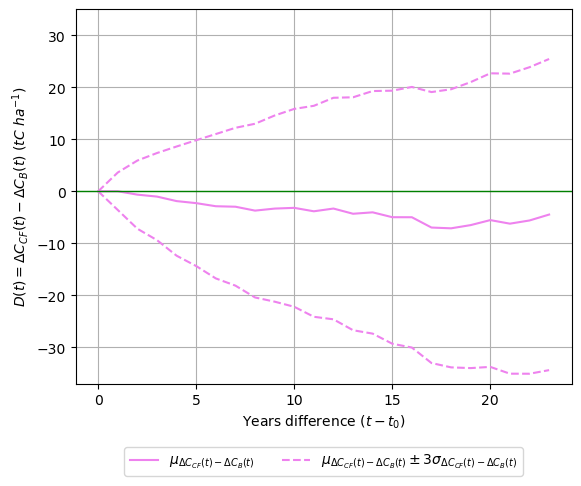

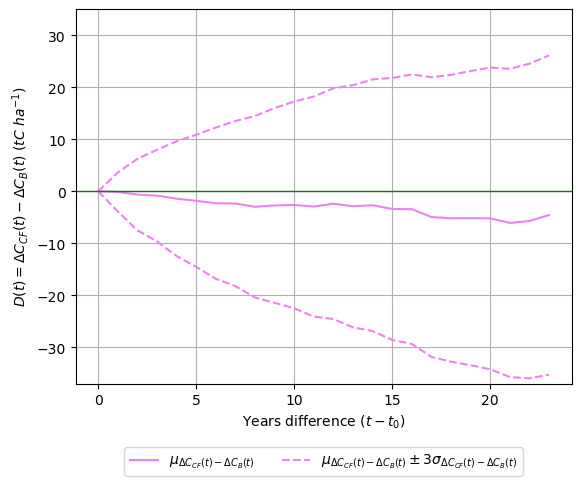

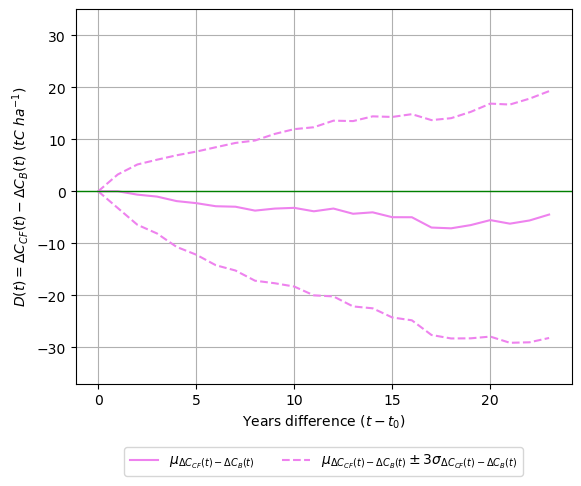

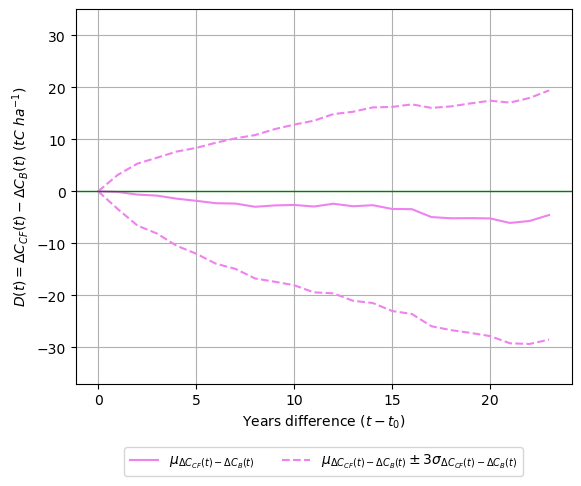

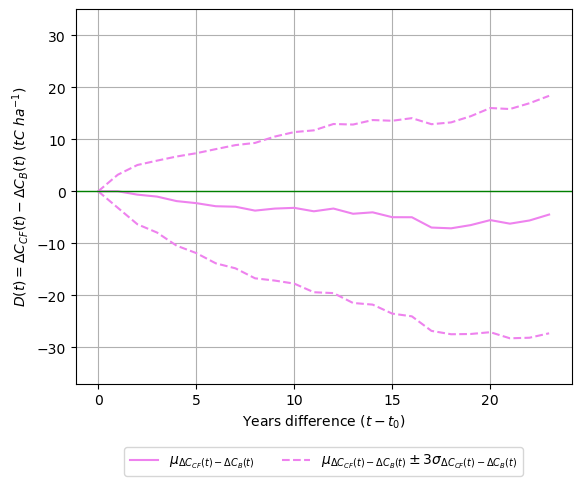

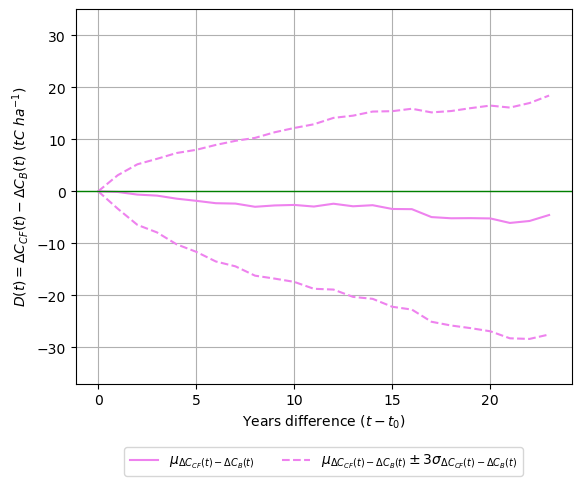

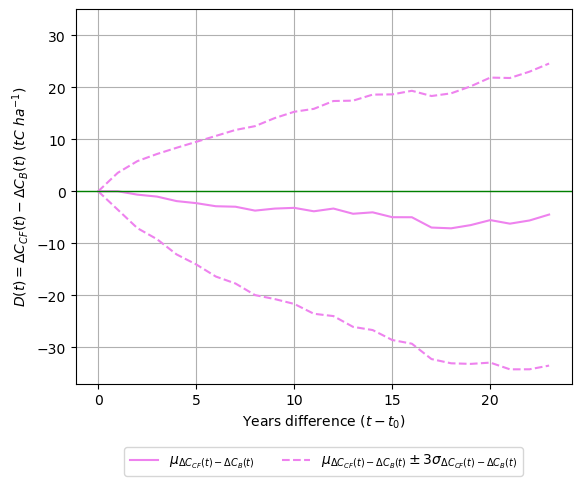

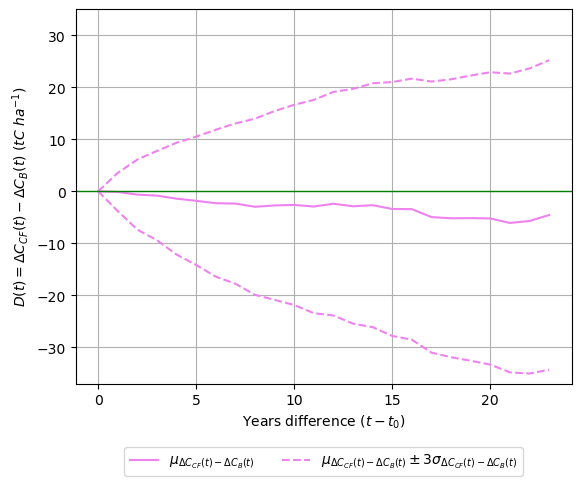

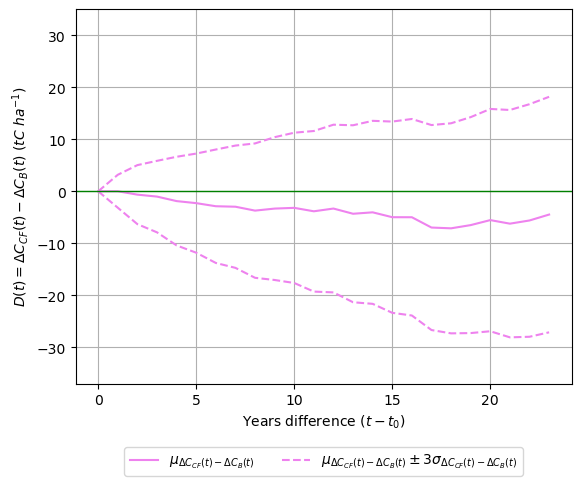

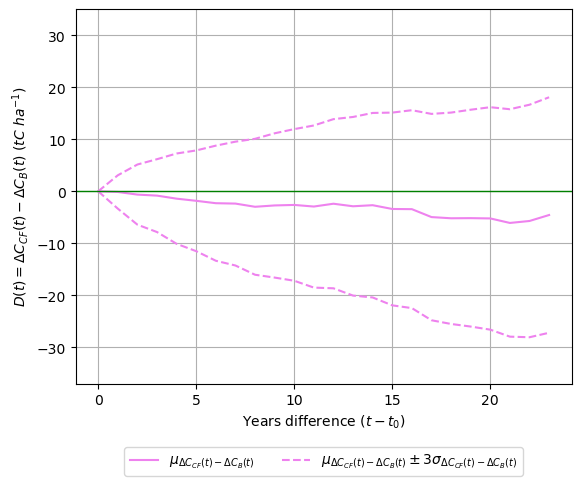

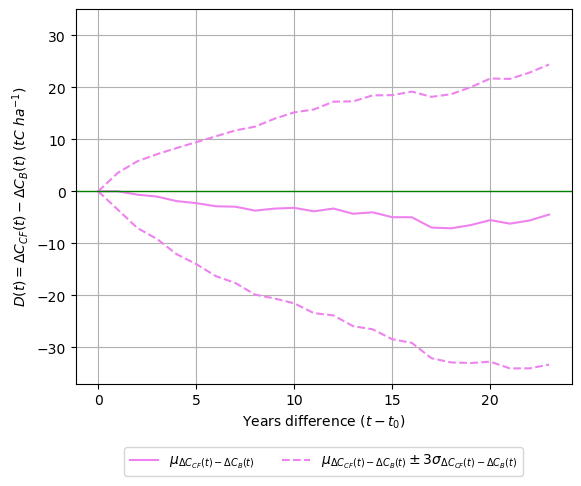

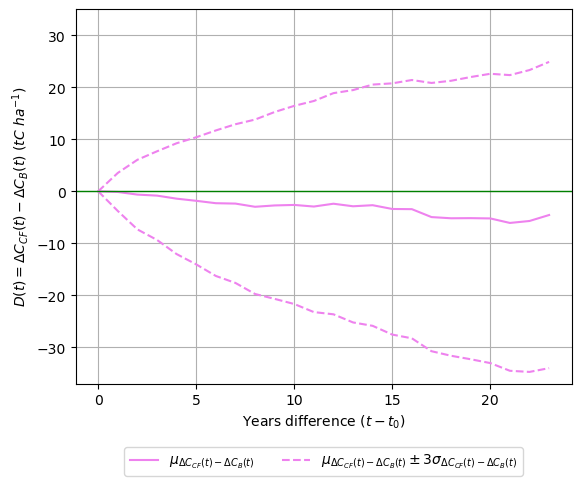

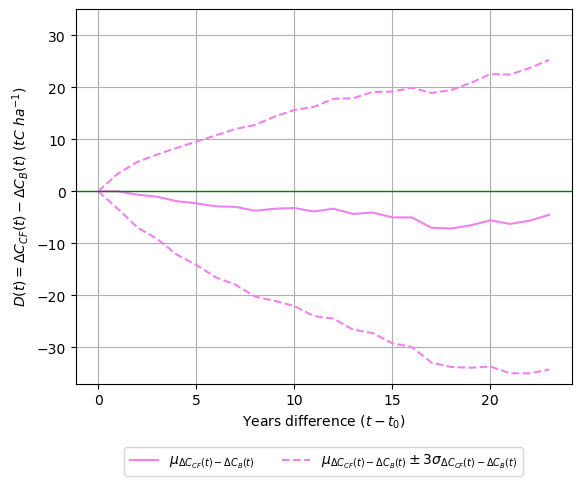

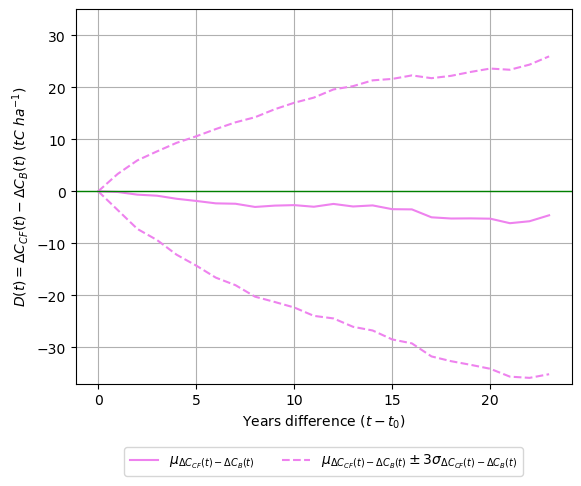

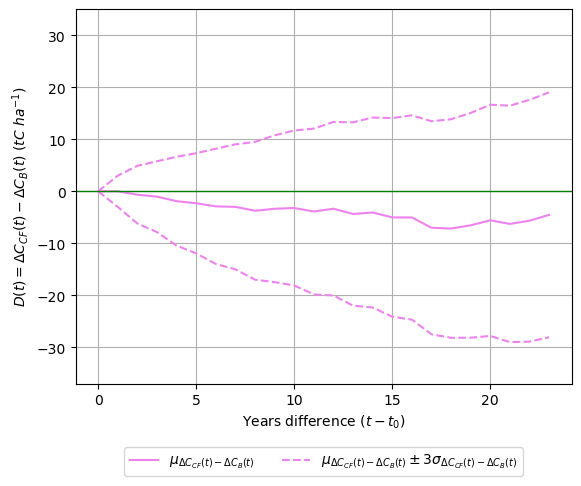

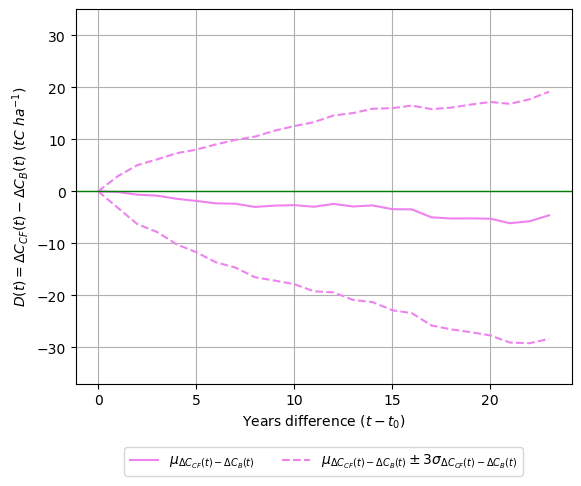

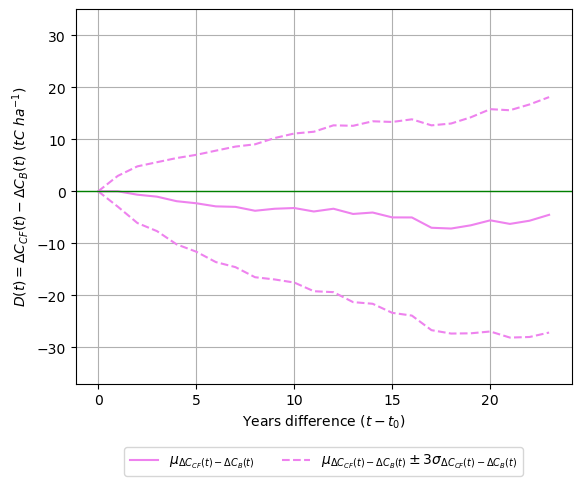

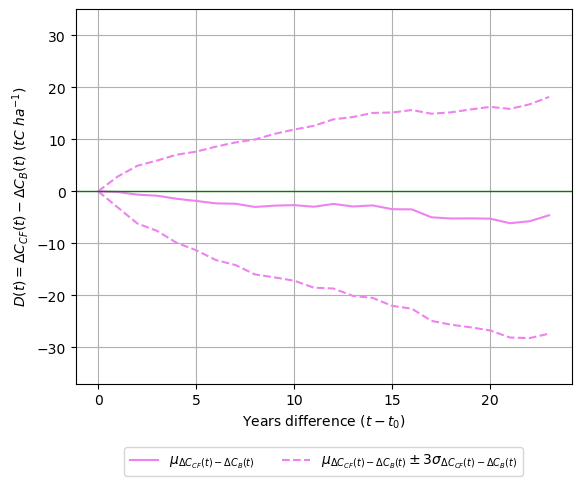

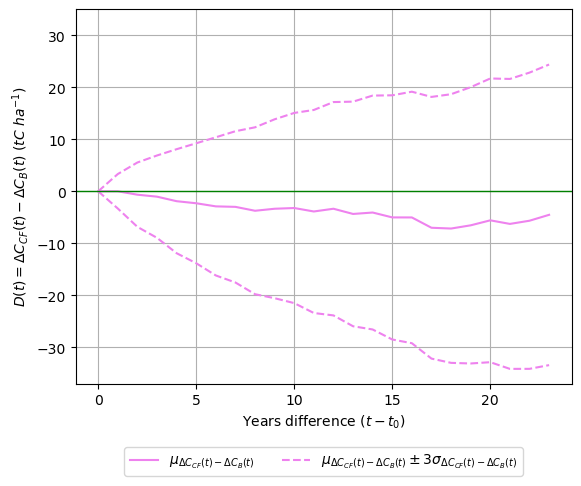

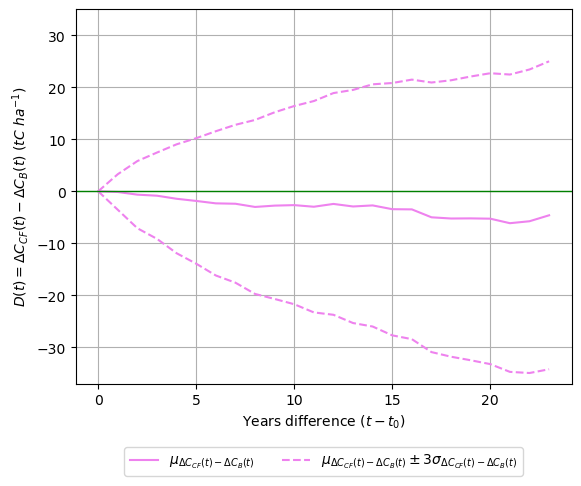

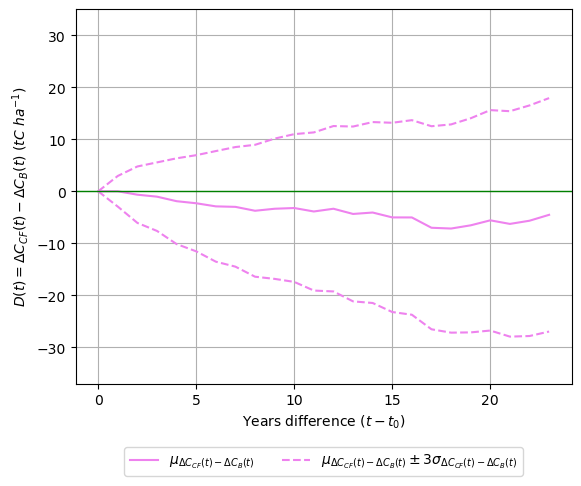

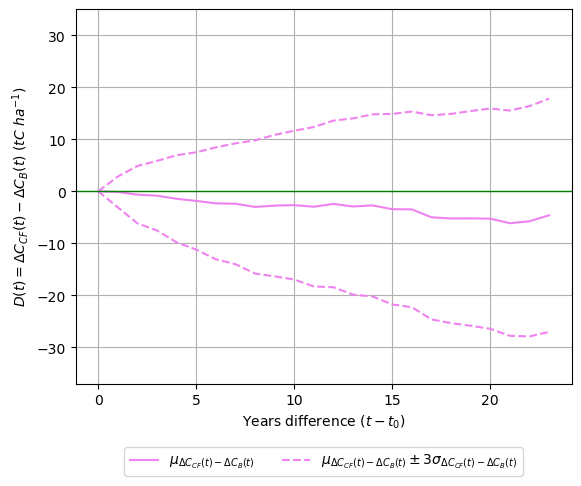

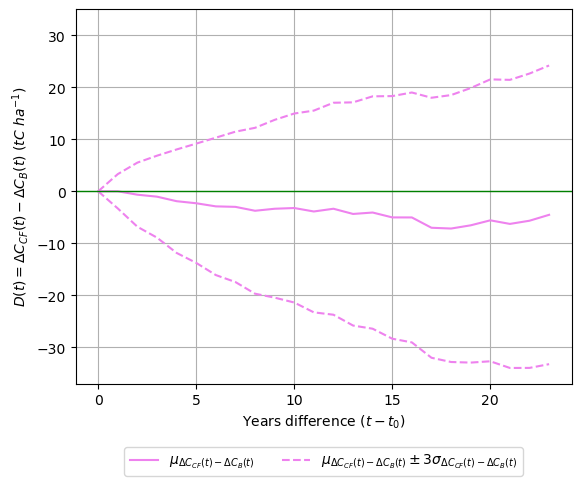

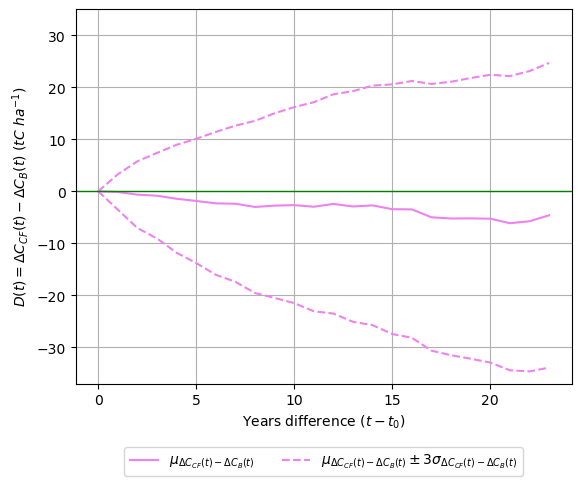

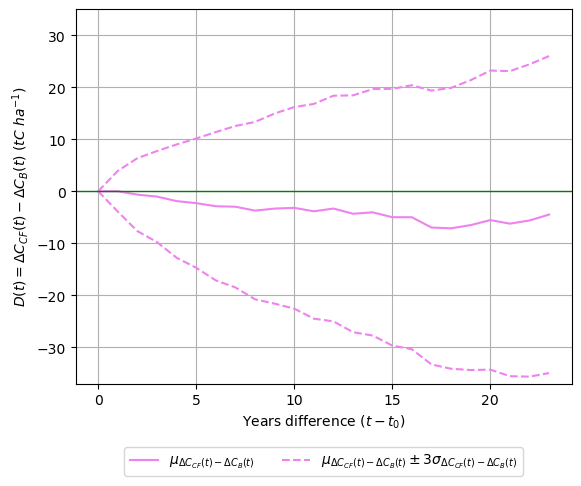

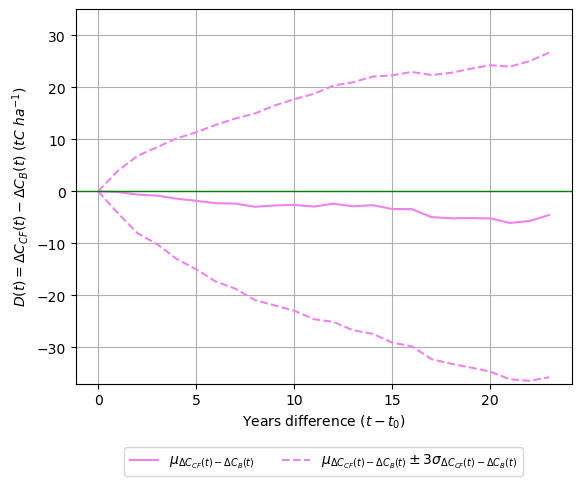

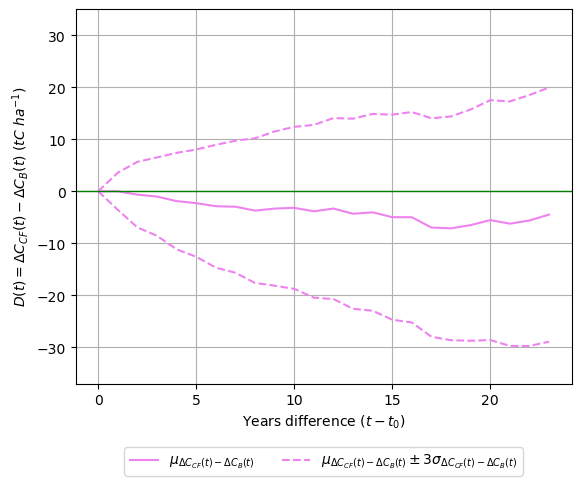

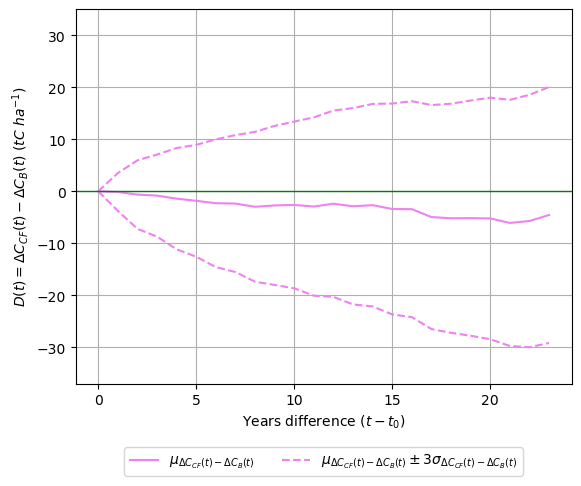

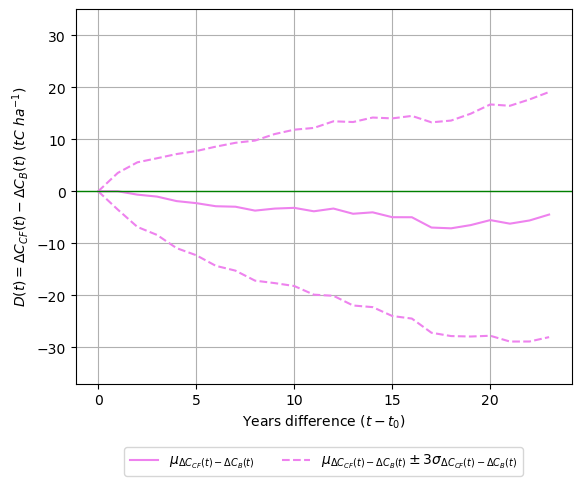

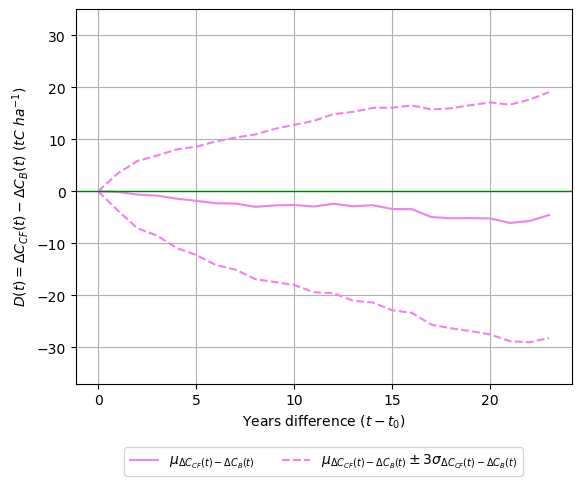

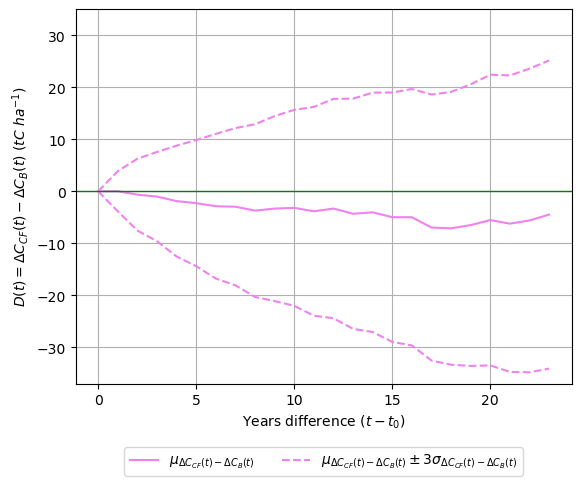

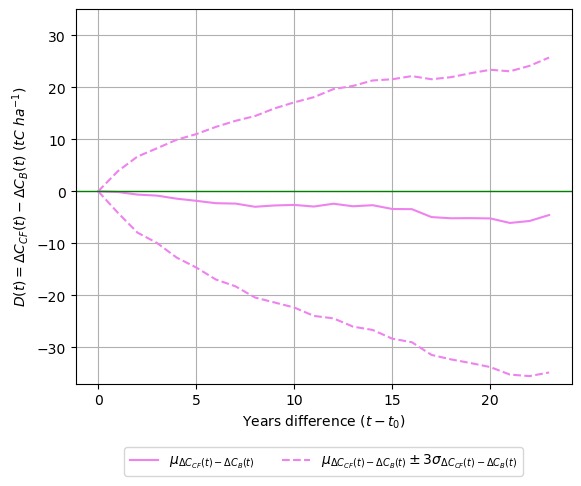

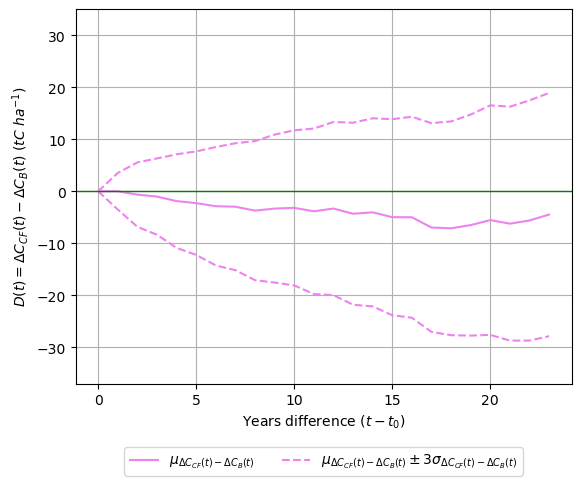

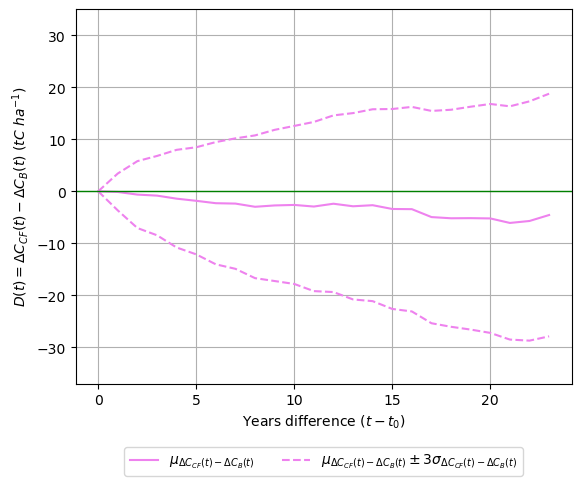

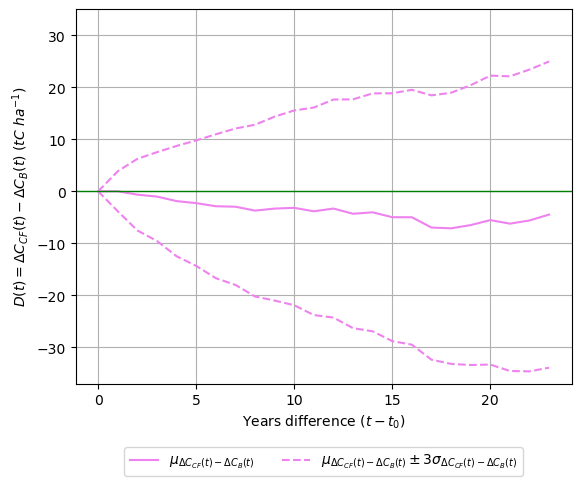

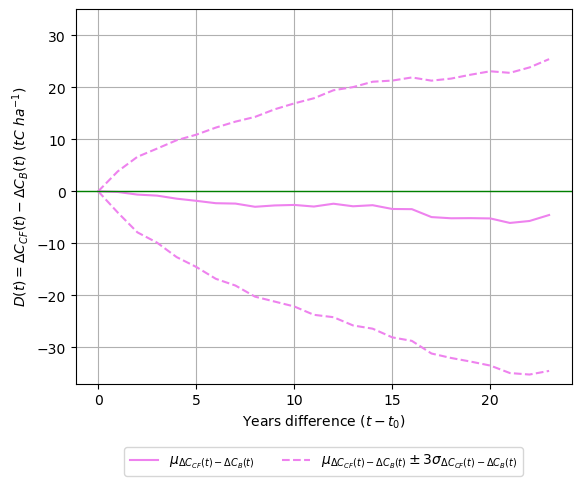

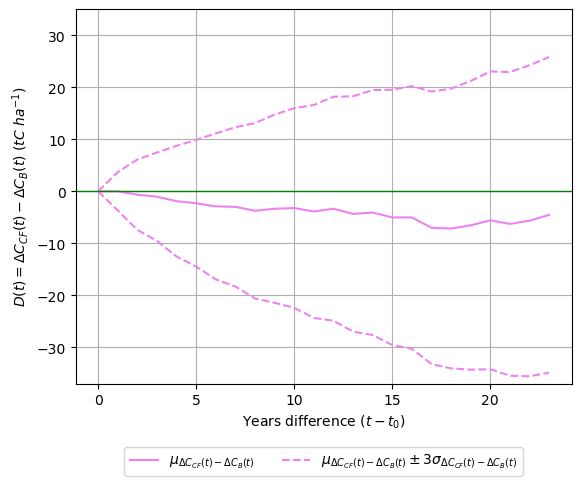

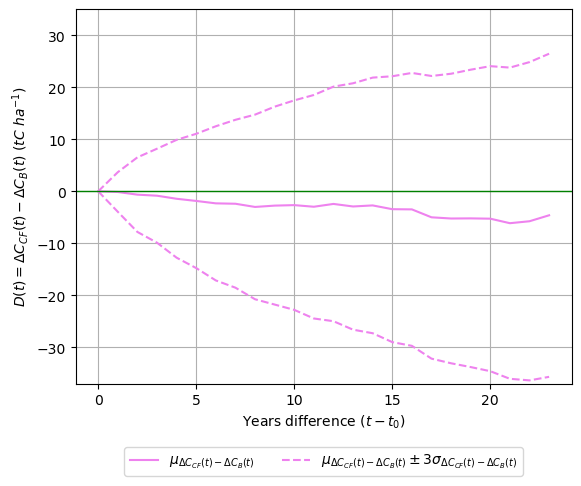

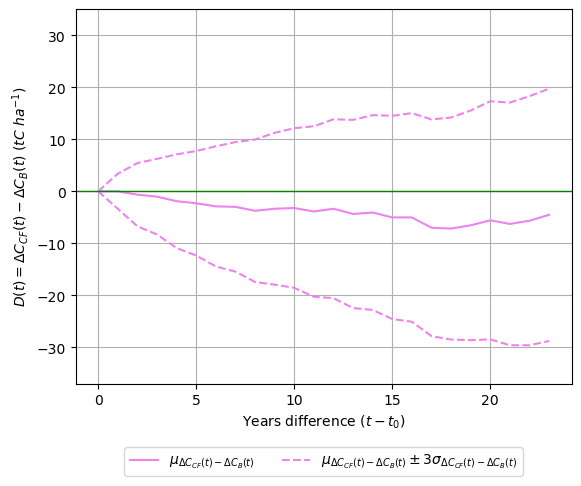

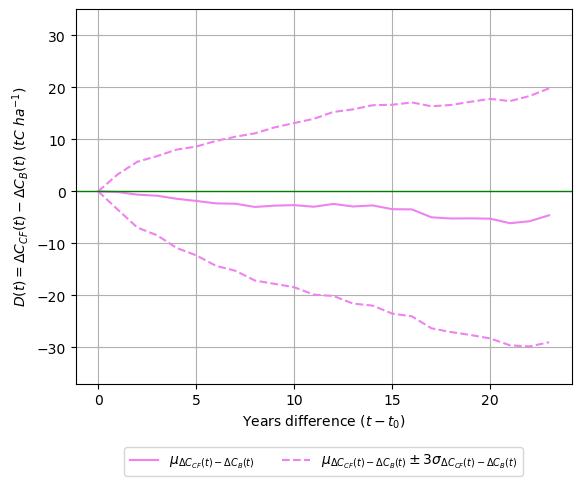

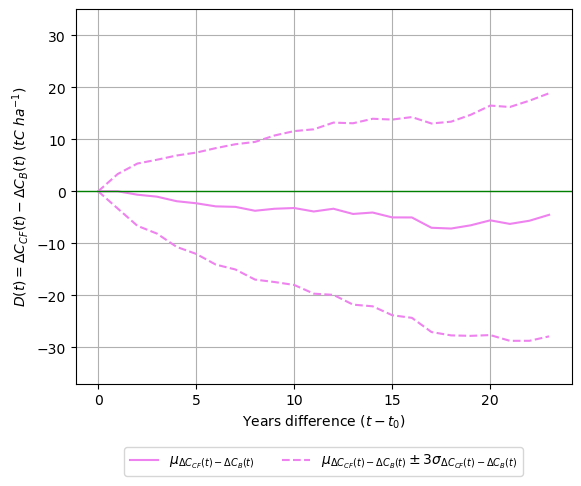

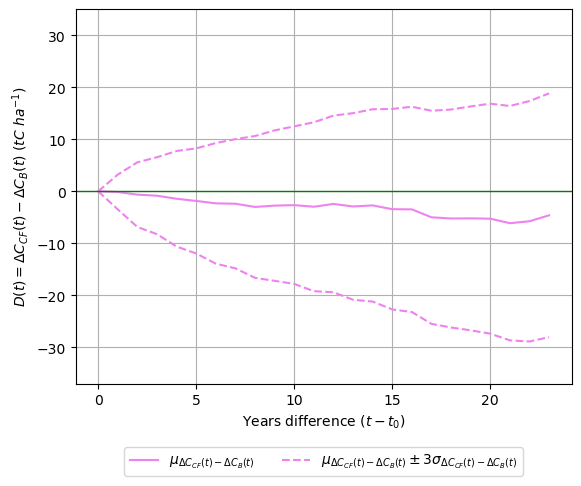

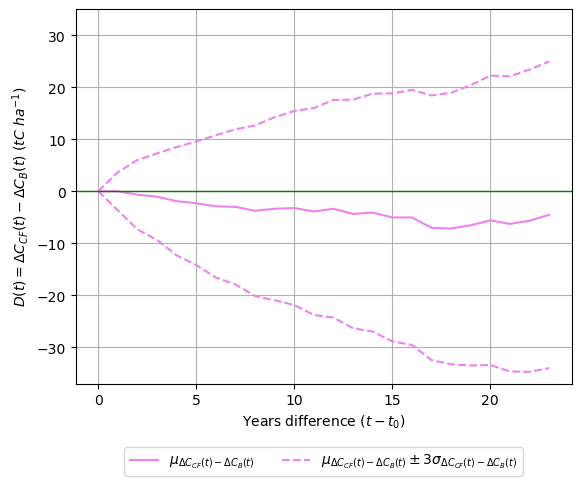

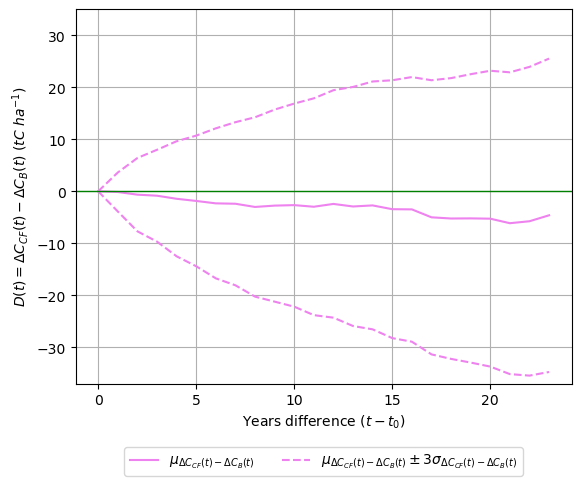

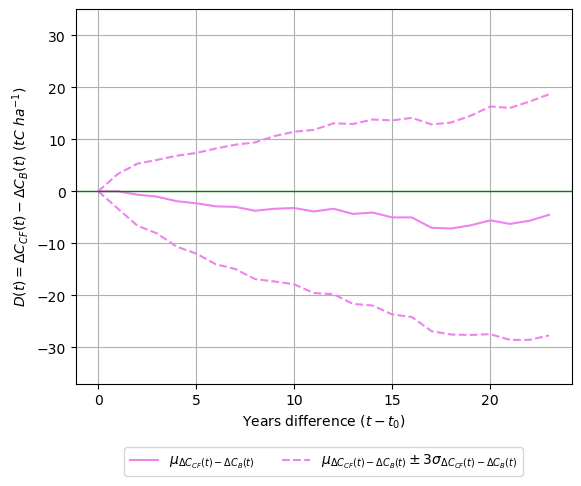

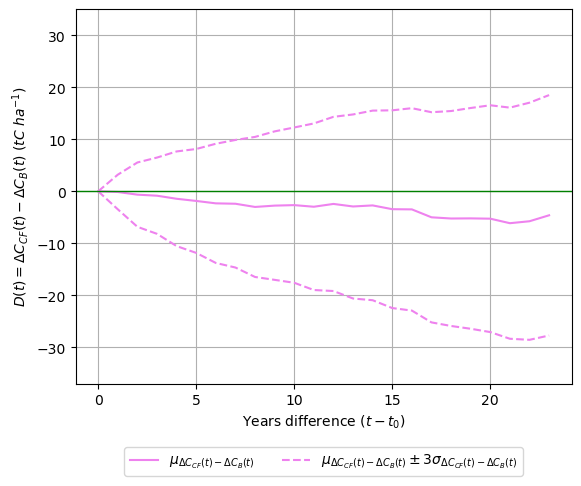

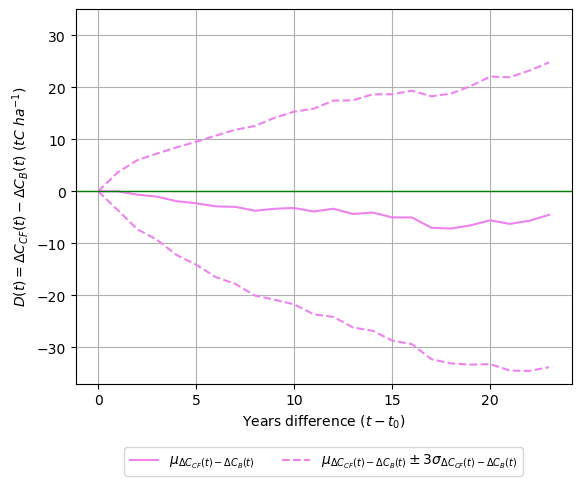

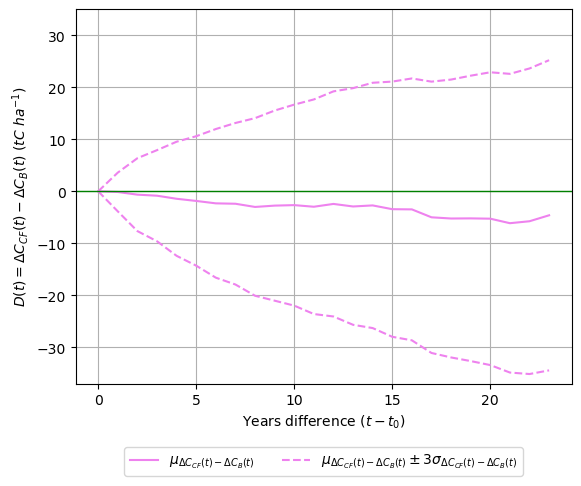

In [14]:
Y0_LEG={}
Y0_PRO={}
coeffs_LEG = {}
coeffs_PRO = {}
sol_odeint_QC_LEG ={}
sol_odeint_QC_PRO ={}

QC_vari_t_analytic_LEG={}
QC_vari_t_analytic_PRO={}
Delta_tf_t0_QC_vari_t_analytic_LEG={}
Delta_tf_t0_QC_vari_t_analytic_PRO={}

dir_path_figures = '../figures/timeseries/carbon_credit_timeseries/static_regional_baseline/'
# Create the repertory if needed
dir_path_figures = Path(dir_path_figures)
dir_path_figures.mkdir(parents=True, exist_ok=True)

for name, (sigma_LEG, sigma_PRO) in configs.items():
    
    # compute the coefficient of the system of differential equation
    coeffs_LEG[f'{name}_LEG'] = coeffs(mean_t_LEG, k_LEG, sigma_LEG, sigma_stress[f'{name}_LEG'], 
                                       baseline_flag=False)

    coeffs_PRO[f'{name}_PRO'] = coeffs(mean_t_PRO, k_PRO, sigma_PRO, sigma_stress[f'{name}_PRO'],
                                       baseline_flag=False)
    
    # compute the initial conditions of the system
    Y0_LEG[f'{name}_LEG'] = init_QC(mean_t_LEG, k_LEG, sigma_LEG, sigma_stress[f'{name}_LEG'])

    Y0_PRO[f'{name}_PRO'] = init_QC(mean_t_PRO, k_PRO, sigma_PRO, sigma_stress[f'{name}_PRO'])
    
    
    # integrate numerically the system and solve it
    sol_odeint_QC_PRO[f'{name}_PRO'] = odeint(
    AMG_system_QC_odeint,
    Y0_PRO[f'{name}_PRO'],
    t_solve,
    args=coeffs_PRO[f'{name}_PRO']
)

    sol_odeint_QC_LEG[f'{name}_LEG'] = odeint(
    AMG_system_QC_odeint,
    Y0_LEG[f'{name}_LEG'],
    t_solve,
    args=coeffs_LEG[f'{name}_LEG']
)
    # compute the mean and uncertainty of absolute SOC stock based on the solution of the system
    QC_vari_t_analytic_LEG[f'{name}_LEG'] = E_sigma_QC_vari_odeint(sol_odeint_QC_LEG[f'{name}_LEG'])
    QC_vari_t_analytic_PRO[f'{name}_PRO'] = E_sigma_QC_vari_odeint(sol_odeint_QC_PRO[f'{name}_PRO'])

    # compute the mean and uncertainty of temporal SOC stock changes based on the solution of the system
    Delta_tf_t0_QC_vari_t_analytic_LEG[f'{name}_LEG']=E_sigma_Delta_tf_t0_QC_vari_odeint(sol_odeint_QC_LEG[f'{name}_LEG'], mean_t_LEG,sigma_LEG)
    Delta_tf_t0_QC_vari_t_analytic_PRO[f'{name}_PRO']=E_sigma_Delta_tf_t0_QC_vari_odeint(sol_odeint_QC_PRO[f'{name}_PRO'], mean_t_PRO,sigma_PRO)

    
    
    # LEG treatment : Compute the mean and uncertainty of D(t) the SOC stock difference between the two management practices scenario
    # under a static standardised baseline
    D_mean_LEG = Delta_tf_t0_QC_vari_t_analytic_LEG[f'{name}_LEG']['E'] - Delta_tf_t0_QC_vari_t_analytic_LEG_baseline['E']
    D_var_LEG = Delta_tf_t0_QC_vari_t_analytic_LEG[f'{name}_LEG']['var'] + Delta_tf_t0_QC_vari_t_analytic_LEG_baseline['sigma']**2
    D_sigma_LEG = np.sqrt(D_var_LEG)

    
    ### Plot timeseries of SOC stock difference between two management series
    ### mu +- z*sigma
    z=3
    plt.figure()
    plt.plot(t_solve, D_mean_LEG, color='violet',label='$\mu_{\Delta C_{CF}(t)- \Delta C_{B}(t)}$')
 
    plt.plot(t_solve, D_mean_LEG+z*D_sigma_LEG,color='violet', linestyle='--', label=rf'$\mu_{{\Delta C_{{CF}}(t)-\Delta C_{{B}}(t)}} \pm {z}\sigma_{{\Delta C_{{CF}}(t)-\Delta C_{{B}}(t)}}$')
    plt.plot(t_solve, D_mean_LEG-z*D_sigma_LEG,color='violet', linestyle='--')
    plt.axhline(0, linestyle='solid', linewidth=1, color='green')
    plt.grid()
    plt.ylabel("$D(t) = \Delta C_{CF}(t) - \Delta C_{B}(t)$ ($tC~ha^{-1}$)")
    plt.xlabel(r'Years difference ($t-t_0$)')

    plt.ylim((-37, 35))
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=2
    )    
    plt.subplots_adjust(bottom=0.1)

    # plt.savefig(dir_path / f'carbon_credit_{name}_LEG_IC_{z}.png',dpi=300, bbox_inches='tight',pad_inches=0.2)

    
    
    # PRO treatment : Compute the mean and uncertainty of D(t) the SOC stock difference between the two management practices scenario
    # under a static standardised baseline
    D_mean_PRO = Delta_tf_t0_QC_vari_t_analytic_PRO[f'{name}_PRO']['E'] - Delta_tf_t0_QC_vari_t_analytic_PRO_baseline['E']
    D_var_PRO = Delta_tf_t0_QC_vari_t_analytic_PRO[f'{name}_PRO']['var'] + Delta_tf_t0_QC_vari_t_analytic_PRO_baseline['sigma']**2
    D_sigma_PRO = np.sqrt(D_var_PRO)

    ### Plot timeseries of SOC stock difference between two management series
    ### mu +- z*sigma
    plt.figure()
    plt.plot(t_solve, D_mean_PRO, color='violet',label='$\mu_{\Delta C_{CF}(t)- \Delta C_{B}(t)}$')

    plt.plot(t_solve, D_mean_PRO+z*D_sigma_PRO,color='violet', linestyle='--', label=rf'$\mu_{{\Delta C_{{CF}}(t)-\Delta C_{{B}}(t)}} \pm {z}\sigma_{{\Delta C_{{CF}}(t)-\Delta C_{{B}}(t)}}$')
    plt.plot(t_solve, D_mean_PRO-z*D_sigma_PRO,color='violet', linestyle='--')
    plt.axhline(0, linestyle='solid', linewidth=1, color='green')
    plt.grid()
    plt.ylabel("$D(t) = \Delta C_{CF}(t) - \Delta C_{B}(t)$ ($tC~ha^{-1}$)")
    plt.xlabel(r'Years difference ($t-t_0$)')
    plt.ylim((-37, 35))
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=2
    )  
    plt.subplots_adjust(bottom=0.1)

    # plt.title(f'{name}_PRO')
    # plt.savefig(dir_path / f'carbon_credit_{name}_PRO_IC_{z}.png',dpi=300, bbox_inches='tight',pad_inches=0.2)


## Compute the uncertainty of SOC stock difference : $\sigma_{D(t)} = \sqrt{\sigma_{\Delta C_{CF}}^2(t) + \sigma_{\Delta C_{Baseline*}}^2(t)}$

In [15]:
# dictionaries that will store the results ('mean', 'var', 'sigma')
# according to the error scenario configuration of the carbon farming
sigma_LEG_carbon_credit_regional_static_baseline ={}
sigma_PRO_carbon_credit_regional_static_baseline ={}


for name, (sigma_LEG, sigma_PRO) in configs.items():
  
    LEG_D_mean = Delta_tf_t0_QC_vari_t_analytic_LEG[f'{name}_LEG']['E'] - Delta_tf_t0_QC_vari_t_analytic_LEG_baseline['E']
    LEG_D_var = Delta_tf_t0_QC_vari_t_analytic_LEG[f'{name}_LEG']['var'] + Delta_tf_t0_QC_vari_t_analytic_LEG_baseline['sigma']**2
    LEG_D_sigma = np.sqrt(LEG_D_var)
    
    PRO_D_mean = Delta_tf_t0_QC_vari_t_analytic_PRO[f'{name}_PRO']['E'] - Delta_tf_t0_QC_vari_t_analytic_LEG_baseline['E']
    PRO_D_var = Delta_tf_t0_QC_vari_t_analytic_PRO[f'{name}_PRO']['var'] + Delta_tf_t0_QC_vari_t_analytic_LEG_baseline['sigma']**2
    PRO_D_sigma = np.sqrt(PRO_D_var)
   
    sigma_LEG_carbon_credit_regional_static_baseline[f'{name}_LEG'] = LEG_D_sigma
    sigma_PRO_carbon_credit_regional_static_baseline[f'{name}_PRO'] = PRO_D_sigma


## Function to plot the evolution of the uncertainty

In [16]:

def init_error_order(label):
    """
    Order wanted :
    0 : sigma_obs for C0
    1 : 10 % of relative uncertainty for C0
    2 : 20 % of relative uncertainty for C0
    """
    if r'\sigma_{C_0} =\sigma_{obs}' in label:
        return 0
    if '10\\%' in label:
        return 1
    if '20\\%' in label:
        return 2
    return 99
   

def plot_sigma(
    sigma_dict,
    sigma_baseline,
    key='stationary',
    dir_path='figures',
    title='Evolution of uncertainty',
    filename='plot_sigma.png',
    ylabel='Uncertainty',
    xlabel='Years',
    label_map=None,
    color_map_dict=None,
    style_map_dict=None
):


    # -------------------
    # Create the repertory if needed
    dir_path = Path(dir_path)
    dir_path.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    
    # -------------------
    # Plot all the curves
    for name, data in sigma_dict.items():
        sigmakI = name.split('_')[1]
        sigmaQCr = name.split('_')[2]

        color = color_map_dict.get(sigmaQCr, 'black') if color_map_dict else 'black'
        style = style_map_dict.get(sigmakI, 'solid') if style_map_dict else 'solid'

        ax.plot(
            data,
            color=color,
            linestyle=style
        )

    # -------------------
    # Titles and labels
    #ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', alpha=0.5)

    # -------------------
    # -------------------
    # Color legends ordered by error in initial conditions
    # with sub group depending on sigma_r
    if color_map_dict and label_map:

        def init_error_order(label):
            if r'\sigma_{C_0} =\sigma_{obs}' in label:
                return 0
            if '10\\%' in label:
                return 1
            if '20\\%' in label:
                return 2
            return 99

        group_006 = []
        group_018 = []

        for k in color_map_dict.keys():
            label = label_map[k]
            entry = (init_error_order(label), k)

            if r'\sigma_r = 0.06' in label:
                group_006.append(entry)
            elif r'\sigma_r = 0.18' in label:
                group_018.append(entry)

        # Sorting to have the wanted order in the legend
        group_006.sort(key=lambda x: x[0])
        group_018.sort(key=lambda x: x[0])

        legend_handles = []
        legend_labels = []

        # ---- Group sigma_r = 0.06 (error scenario using Party_SOC to initialise r)
        legend_handles.append(Line2D([], [], linestyle='None'))
        legend_labels.append(r'$PARTY_{SOC}$ $\sigma_r = 0.06$ :')
      
        for _, k in group_006:
            legend_handles.append(Line2D([0], [0], color=color_map_dict[k], lw=1))
            legend_labels.append(label_map[k].split(',')[0])

        # ---- Group sigma_r = 0.18 (error scenario using default value to initialise r)
        legend_handles.append(Line2D([], [], linestyle='None'))
        legend_labels.append(r'Default $\sigma_r = 0.18$ :')

        for _, k in group_018:
            legend_handles.append(Line2D([0], [0], color=color_map_dict[k], lw=1))
            legend_labels.append(label_map[k].split(',')[0])

        legend1 = ax.legend(
            legend_handles,
            legend_labels,
            title='Errors on initialisation $r, C_{0}$',
            loc='upper left',
            bbox_to_anchor=(1.02, 0.9),
            borderaxespad=0,
            handlelength=2
        )

        ax.add_artist(legend1)
        header = ax.legend(
        [],
        [],
        title=r"Error scenarios for $\Delta SOC_{stock} (CF)$:",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
        frameon=True,
    )
        ax.add_artist(header)


    # -------------------
    # Legend linestyles depending on error scenario to compute intermediate variable uncertainty
    # sigma_I and sigma_k
    if style_map_dict:
        style_proxies = [
            Line2D([0], [0], color='black', lw=1, linestyle=style_map_dict[k])
            for k in style_map_dict.keys()
        ]
        style_labels = [label_map[k] if label_map and k in label_map else k
                                for k in style_map_dict.keys()]

        ax.legend(
            style_proxies,
            style_labels,
            title='Error on inputs for $I, k$',
            loc='upper left',
            bbox_to_anchor=(1.02, 0.23),
            borderaxespad=0
        )
        

   # -------------------
    # Adjust space for legends
    fig.subplots_adjust(right=0.7)

    # -------------------
    # Save figures
    # fig.savefig(dir_path / filename, dpi=300, bbox_inches='tight',pad_inches=1)
    # plt.close(fig)


### Reduced dataset by keeping only opti and pessim error scenario configuration

In [17]:

keywords = ["opti", "pessim"]
sigma_LEG_opti_pessim = {k: v for k, v in sigma_LEG_carbon_credit_regional_static_baseline.items() if any(word in k for word in keywords)}
sigma_PRO_opti_pessim = {k: v for k, v in sigma_PRO_carbon_credit_regional_static_baseline.items() if any(word in k for word in keywords)}


## Figures : Evolution of the uncertainty of the difference of SOC stock between two management practices (Fig. 14)

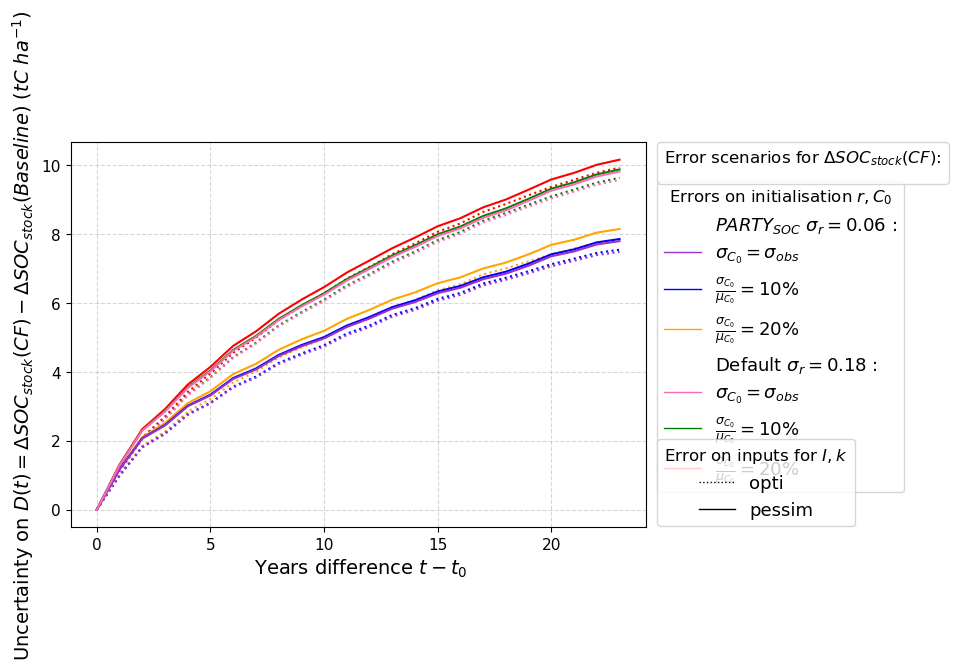

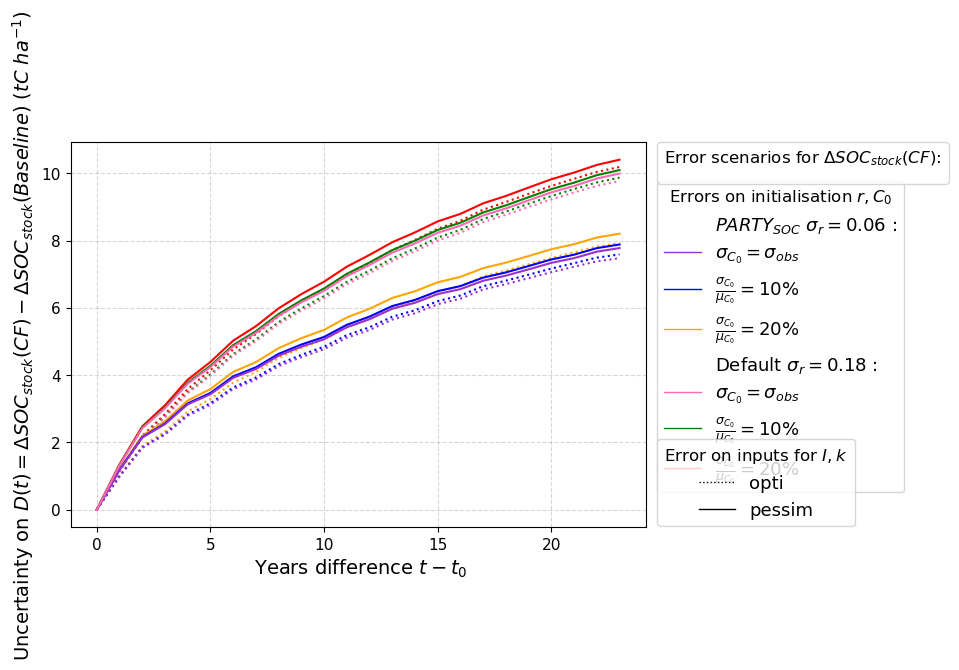

In [18]:
# dictionary that defines the legend names
# according to the error scenario configuration 
label_map = {
    'local':    r'$\frac{\sigma_{C_0}}{\mu_{C_0}}=10\%$, $\sigma_r = 0.06$',
    'large':    r'$\frac{\sigma_{C_0}}{\mu_{C_0}}=20\%$, $\sigma_r = 0.18$',
    'localdef': r'$\frac{\sigma_{C_0}}{\mu_{C_0}}=10\%$, $\sigma_r = 0.18$',
    'largeRE':  r'$\frac{\sigma_{C_0}}{\mu_{C_0}}=20\%$, $\sigma_r = 0.06$',
    'mesdef': r'$\sigma_{C_0} =\sigma_{obs}$, $\sigma_r = 0.18$',
    'mesRE':  r'$\sigma_{C_0} =\sigma_{obs}$, $\sigma_r = 0.06$',
    'opti' :'opti',
    'pessim':'pessim'
}  
# dictionary that defines the color of the curve according to the error scenario configuration for initial conditions
color_map_dict = {'local' : 'blue', 'large': 'red', 'largeRE':'orange', 'localdef':'green', 'mesRE':'darkorchid', 'mesdef':'hotpink'}

# dictionary that defines the linestyle of the curve according to the error scenario configuration 
# for intermediate variables I and k
style_map_dict = {'opti':'dotted', 'pessim':'solid'}

# directory to save the fig, for now the line savefig is commented in the function
dir_path_figures = '../figures/uncertainty_evolution/carbon_credit/regional_static_baseline/'

# Axis label
ylabel = 'Uncertainty on $D(t) = \Delta SOC_{stock}(CF) -\Delta SOC_{stock}(Baseline) $ ($tC~ha^{-1}$)'
xlabel =' Years difference $t-t_0$'

## Call the function to plot
# LEG - Evolution of SOC stock difference uncertainty for non-stationary case, between two management practices
# under a static standardised baseline
plot_sigma(
    sigma_LEG_opti_pessim,
    Delta_tf_t0_QC_vari_t_analytic_LEG_baseline,
    key='vari',
    dir_path=dir_path_figures,
    title='LEG - Evolution of SOC stock difference uncertainty for non-stationary case',
    filename='LEG_evolution_non_stationary_uncertainty_static_standard_baseline.png',
    ylabel=ylabel,
    xlabel=xlabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict
)

# PRO - Evolution of SOC stock difference uncertainty for non-stationary case, between two management practices
# under a static standardised baseline
plot_sigma(
    sigma_PRO_opti_pessim,
    Delta_tf_t0_QC_vari_t_analytic_LEG_baseline,
    key='vari',
    dir_path=dir_path_figures,
    title='PRO - Evolution of SOC stock difference uncertainty for non-stationary case',
    filename='PRO_evolution_non_stationary_uncertainty_static_standard_baseline.png',
    ylabel=ylabel,
    xlabel=xlabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict
)


## Figures : Evolution of the contribution of the baseline uncertainty to the total uncertainty of the difference of SOC stock, between two maagement practices (Fig. S15)

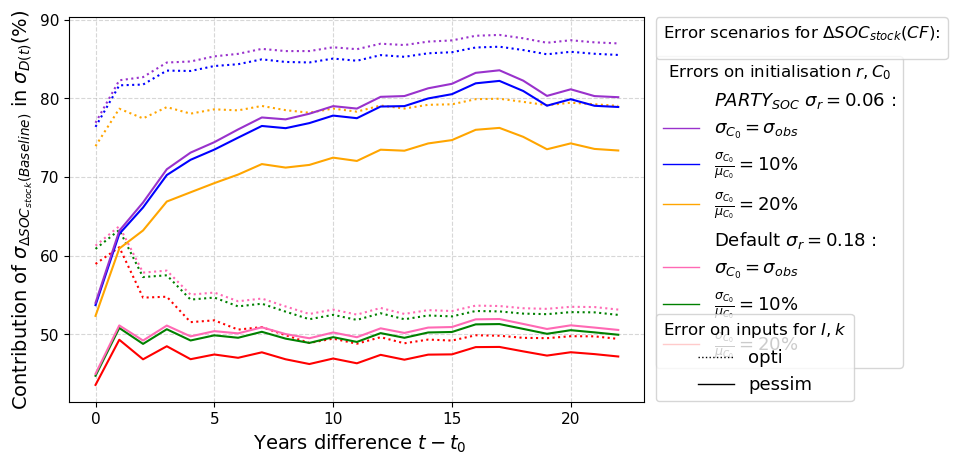

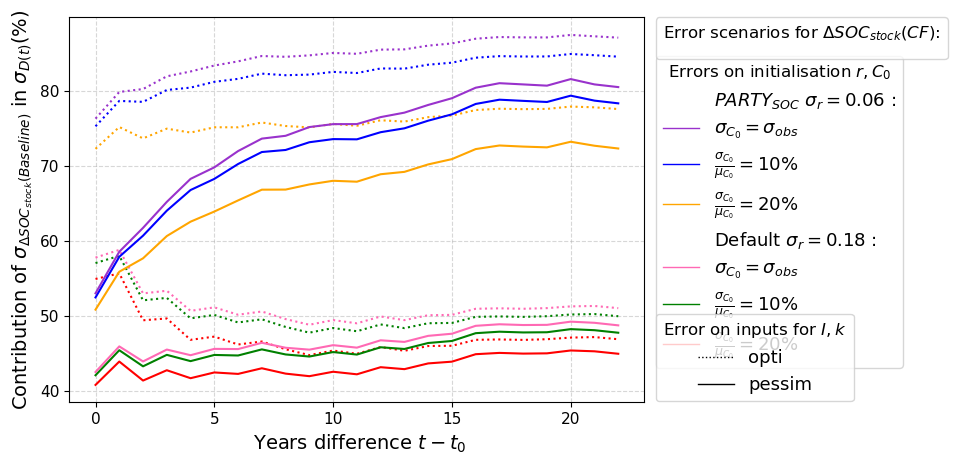

In [19]:
contrib_baseline_sigma_LEG={}
contrib_baseline_sigma_PRO={}
for key in sigma_LEG_opti_pessim.keys():
    contrib_baseline_sigma_LEG[key] = 100 * Delta_tf_t0_QC_vari_t_analytic_LEG_baseline['sigma'][1:]**2 / sigma_LEG_opti_pessim[key][1:]**2
    
for key in sigma_PRO_opti_pessim.keys():
    contrib_baseline_sigma_PRO[key] = 100 * Delta_tf_t0_QC_vari_t_analytic_LEG_baseline['sigma'][1:]**2 / sigma_PRO_opti_pessim[key][1:]**2



# dictionary that defines the legend names
# according to the error scenario configuration 
label_map = {
    'local':    r'$\frac{\sigma_{C_0}}{\mu_{C_0}}=10\%$, $\sigma_r = 0.06$',
    'large':    r'$\frac{\sigma_{C_0}}{\mu_{C_0}}=20\%$, $\sigma_r = 0.18$',
    'localdef': r'$\frac{\sigma_{C_0}}{\mu_{C_0}}=10\%$, $\sigma_r = 0.18$',
    'largeRE':  r'$\frac{\sigma_{C_0}}{\mu_{C_0}}=20\%$, $\sigma_r = 0.06$',
    'mesdef': r'$\sigma_{C_0} =\sigma_{obs}$, $\sigma_r = 0.18$',
    'mesRE':  r'$\sigma_{C_0} =\sigma_{obs}$, $\sigma_r = 0.06$',
    'opti' :'opti',
    'pessim':'pessim'
}  

# dictionary that defines the color of the curve according to the error scenario configuration for initial conditions
color_map_dict = {'local' : 'blue', 'large': 'red', 'largeRE':'orange', 'localdef':'green', 'mesRE':'darkorchid', 'mesdef':'hotpink'}

# dictionary that defines the linestyle of the curve according to the error scenario configuration 
# for intermediate variables I and k
style_map_dict = {'opti':'dotted', 'pessim':'solid'}

# directory to save the fig, for now the line savefig is commented in the function
dir_path_figures = '../figures/uncertainty_evolution/carbon_credit/regional_static_baseline/'

# Axis label
ylabel = 'Contribution of $\sigma_{\Delta SOC_{stock}(Baseline)}$ in $\sigma_{D(t)}$(%)'
xlabel =' Years difference $t-t_0$'


## Call the function to plot


# LEG - Evolution of baseline contribution to total D uncertainty
plot_sigma(
    contrib_baseline_sigma_LEG,
    Delta_tf_t0_QC_vari_t_analytic_LEG_baseline,
    key='vari',
    dir_path=dir_path_figures,
    title='LEG - Evolution of baseline contribution to total D uncertainty',
    filename='contribution_baseline_LEG_evolution_stationary_uncertainty_all_scenario.png',
    ylabel=ylabel,
    xlabel=xlabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict
)

# PRO - Evolution of baseline contribution to total D uncertainty
plot_sigma(
    contrib_baseline_sigma_PRO,
    Delta_tf_t0_QC_vari_t_analytic_LEG_baseline,
    key='vari',
    dir_path=dir_path_figures,
    title='PRO - Evolution of baseline contribution to total D uncertainty',
    filename='contribution_baseline_PRO_evolution_stationary_uncertainty_all_scenario.png',
    ylabel=ylabel,
    xlabel=xlabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict
)